## Librairies

In [3]:
!pip install meteostat
!pip install matplotlib
!pip install datetime
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install --upgrade meteostat
!pip install --upgrade meteostat -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from meteostat import Point, daily, stations
import io
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
## from google.colab import files

# 1. Creation of the Dataset
## 1.1. Others data
### 1.1.1. Choice of the products

In [23]:
products = [
    {"id":"1",  "nom":"Instant Noodles Indomie",      "cat":"Noodles",     "price":5000,  "qty":55,  "s_heat":0.05, "s_tourism":0.05},
    {"id":"2",  "nom":"Premium Rice 5kg",             "cat":"Rice",        "price":76000, "qty":14,  "s_heat":0.00, "s_tourism":0.00},
    {"id":"3",  "nom":"Cooking Oil 2L",               "cat":"Oil",         "price":34000, "qty":10,  "s_heat":0.00, "s_tourism":0.00},
    {"id":"4",  "nom":"White Sugar 1kg",              "cat":"Sugar",       "price":16000, "qty":16,  "s_heat":0.00, "s_tourism":0.00},
    {"id":"5",  "nom":"Wheat Flour 1kg",              "cat":"Flour",       "price":13000, "qty":11,  "s_heat":0.00, "s_tourism":0.00},
    {"id":"6",  "nom":"Mineral Water 600ml",          "cat":"Water",       "price":3200,  "qty":100, "s_heat":0.20, "s_tourism":0.15},
    {"id":"7",  "nom":"Sweet Iced Tea 450ml",         "cat":"Beverage",    "price":5000,  "qty":75,  "s_heat":0.15, "s_tourism":0.15},
    {"id":"8",  "nom":"Ground Coffee Sachets x10",    "cat":"Coffee",      "price":17500, "qty":28,  "s_heat":0.10, "s_tourism":0.05},
    {"id":"9",  "nom":"Potato Chips 68g",             "cat":"Snack",       "price":9500,  "qty":42,  "s_heat":0.05, "s_tourism":0.20},
    {"id":"10", "nom":"Cheese Wafer",                 "cat":"Snack",       "price":2800,  "qty":60,  "s_heat":0.05, "s_tourism":0.15},
    {"id":"11", "nom":"Antibacterial Soap 90g",       "cat":"Hygiene",     "price":5200,  "qty":18,  "s_heat":0.00, "s_tourism":0.05},
    {"id":"12", "nom":"Shampoo 170ml",                "cat":"Hygiene",     "price":22000, "qty":9,   "s_heat":0.00, "s_tourism":0.10},
    {"id":"13", "nom":"Laundry Detergent 800g",       "cat":"Household",   "price":18000, "qty":8,   "s_heat":0.00, "s_tourism":0.00},
    {"id":"14", "nom":"UHT Milk 250ml",               "cat":"Dairy",       "price":5200,  "qty":48,  "s_heat":0.05, "s_tourism":0.05},
    {"id":"15", "nom":"Eggs (pack of 10)",            "cat":"Dairy",       "price":27000, "qty":22,  "s_heat":0.00, "s_tourism":0.00},
    {"id":"16", "nom":"White Sandwich Bread",         "cat":"Bakery",      "price":14000, "qty":32,  "s_heat":0.05, "s_tourism":0.05},
    {"id":"17", "nom":"Paracetamol 500mg x10",        "cat":"Pharmacy",    "price":8000,  "qty":20,  "s_heat":0.00, "s_tourism":0.00},
    {"id":"18", "nom":"Mobile Top-Up Card Rp 20k",    "cat":"Telco",       "price":19500, "qty":25,  "s_heat":0.00, "s_tourism":0.25},
    {"id":"19", "nom":"Frozen Meatballs 200g",        "cat":"Frozen",      "price":12000, "qty":30,  "s_heat":0.05, "s_tourism":0.00},
    {"id":"20", "nom":"AA Batteries (pack of 4)",     "cat":"Electronics", "price":15000, "qty":14,  "s_heat":0.00, "s_tourism":0.10},
]

### 1.1.2. Get weather by python

Check of the first data of 2023:
         time  temp  prcp
0  2023-01-01  21.4   1.6
1  2023-01-02  22.4   0.8
2  2023-01-03  21.8   2.2
3  2023-01-04  21.8   4.0
4  2023-01-05  22.2   0.9
5  2023-01-06  23.0   0.6
6  2023-01-07  23.0   1.3
7  2023-01-08  22.5   2.5
8  2023-01-09  22.3   3.2
9  2023-01-10  22.4   0.7


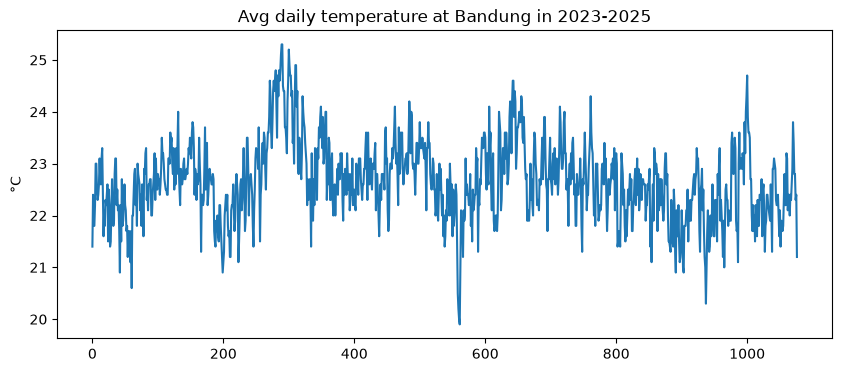

In [24]:
"""
# Parameters
start = datetime(2023, 1, 1)
end = datetime(2025, 12, 31)
POINT = Point(-6.9147, 107.6098, 768)
#nearby_stations = stations.nearby(POINT, limit=4)
#bandung_station = nearby_stations.index[0] if not nearby_stations.empty else '96781'
bandung_station = '96781'
stations.max_age = 0
daily.max_age = 0

# Fetch
data = daily(bandung_station, start, end)
df_meteo = data.fetch()
df_clean_meteo = df_meteo[['temp', 'prcp']]
"""
# read local csv
##uploaded = files.upload()
##df_clean_meteo = pd.read_csv('/content/bandung_meteo_3y.csv')
df_clean_meteo = pd.read_csv('Data/bandung_meteo_3y.csv')
# Check
print("Check of the first data of 2023:")
print(df_clean_meteo.head(10))
df_clean_meteo['temp'].plot(figsize=(10, 4), title="Avg daily temperature at Bandung in 2023-2025")
plt.ylabel("°C")
plt.show()

### 1.1.3. Get tourism governement website

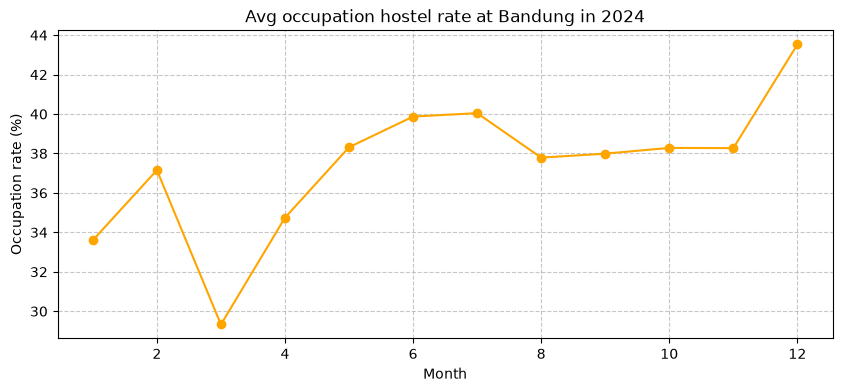

,tahun,kode_bulan,tingkat_penghunian_kamar
0,2024,1,33.601111
1,2024,2,37.154444
2,2024,3,29.326667
3,2024,4,34.743333
4,2024,5,38.316667
5,2024,6,39.871111
6,2024,7,40.045556
7,2024,8,37.790000
8,2024,9,37.991111
9,2024,10,38.283333


In [25]:
# read local csv
##uploaded = files.upload()
##df_tourism = pd.read_csv('/content/java_tourisme_2024.csv')
df_tourism = pd.read_csv('Data/java_tourisme_2024.csv')
df_tourism.head()

# get the monthly average
df_tourism.columns = df_tourism.columns.str.lower().str.strip() # normalize column names to lower case to avoid issues
df_monthly_tourism = df_tourism.groupby(['tahun', 'kode_bulan'])['tingkat_penghunian_kamar'].mean().reset_index() # Grouping
df_monthly_tourism = df_monthly_tourism.sort_values(by='kode_bulan') # Sort by month code

# Check
plt.figure(figsize=(10, 4))
plt.plot(df_monthly_tourism['kode_bulan'], df_monthly_tourism['tingkat_penghunian_kamar'], marker='o', linestyle='-', color='orange')
plt.title("Avg occupation hostel rate at Bandung in 2024")
plt.xlabel("Month")
plt.ylabel("Occupation rate (%)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

display(df_monthly_tourism)

Data augmentation as only data from 2024 available

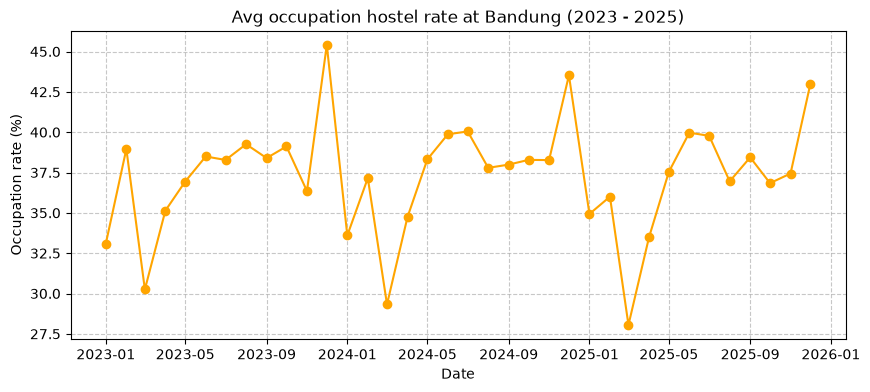

,tahun,kode_bulan,tingkat_penghunian_kamar
0,2023,1,33.099272
1,2023,2,38.957302
2,2023,3,30.254642
3,2023,4,35.137967
4,2023,5,36.940741
5,2023,6,38.495089
6,2023,7,38.277890
7,2023,8,39.254705
8,2023,9,38.395571
9,2023,10,39.115624


In [26]:
np.random.seed(42)
df_monthly_tourism_base = df_tourism.groupby(['tahun', 'kode_bulan'])['tingkat_penghunian_kamar'].mean().reset_index()

# Create 2023 and 2025 with noise
df_tourism_2023 = df_monthly_tourism_base.copy()
df_tourism_2023['tahun'] = 2023
df_tourism_2023['tingkat_penghunian_kamar'] += np.random.uniform(-2, 2, len(df_tourism_2023))
df_tourism_2025 = df_monthly_tourism_base.copy()
df_tourism_2025['tahun'] = 2025
df_tourism_2025['tingkat_penghunian_kamar'] += np.random.uniform(-2, 2, len(df_tourism_2025))

# Compile
df_monthly_tourism = pd.concat([df_tourism_2023, df_monthly_tourism_base, df_tourism_2025], ignore_index=True)
df_monthly_tourism = df_monthly_tourism.sort_values(by=['tahun', 'kode_bulan']).reset_index(drop=True)

# Check
df_monthly_tourism['Date_plot'] = pd.to_datetime(
    df_monthly_tourism['tahun'].astype(str) + '-' + 
    df_monthly_tourism['kode_bulan'].astype(str) + '-01'
)
plt.figure(figsize=(10, 4))
plt.plot(df_monthly_tourism['Date_plot'], df_monthly_tourism['tingkat_penghunian_kamar'], marker='o', color='orange')
plt.title("Avg occupation hostel rate at Bandung (2023 - 2025)")
plt.ylabel("Occupation rate (%)")
plt.xlabel("Date")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
df_monthly_tourism = df_monthly_tourism.drop(columns=['Date_plot'])

display(df_monthly_tourism.head(15))

## 1.2. Script to simulate the demand
### 1.2.1. Preparation of the dataset

In [27]:
# A- Merge meteo and tourism

meteo = df_clean_meteo.copy()
tourisme = df_monthly_tourism.copy()
if 'time' in meteo.columns:
    meteo = meteo.rename(columns={'time': 'Date'})
meteo['Date'] = pd.to_datetime(meteo['Date'])
meteo['tahun'] = meteo['Date'].dt.year
meteo['kode_bulan'] = meteo['Date'].dt.month
meteo = meteo.merge(
    tourisme[['tahun', 'kode_bulan', 'tingkat_penghunian_kamar']],
    on=['tahun', 'kode_bulan'], how='left')
meteo = meteo.rename(columns={'tingkat_penghunian_kamar': 'Avg_tourism'})
meteo = meteo.drop(columns=['tahun', 'kode_bulan'])
display(meteo.head())

,Date,temp,prcp,Avg_tourism
0,2023-01-01,21.4,1.6,33.099272
1,2023-01-02,22.4,0.8,33.099272
2,2023-01-03,21.8,2.2,33.099272
3,2023-01-04,21.8,4.0,33.099272
4,2023-01-05,22.2,0.9,33.099272


In [30]:
# B- Merge with products

if isinstance(products, list):
    df_products = pd.DataFrame(products)
else:
    df_products = pd.DataFrame(products)

df_complet = meteo.merge(df_products, how='cross')
df_complet = df_complet.sort_values(by=['nom', 'Date']).reset_index(drop=True)
display(df_complet.head(10))
display(df_complet.info())

,Date,temp,prcp,Avg_tourism,id,nom,cat,price,qty,s_heat,s_tourism
0,2023-01-01,21.4,1.6,33.099272,20,AA Batteries (pack of 4),Electronics,15000,14,0.0,0.1
1,2023-01-02,22.4,0.8,33.099272,20,AA Batteries (pack of 4),Electronics,15000,14,0.0,0.1
2,2023-01-03,21.8,2.2,33.099272,20,AA Batteries (pack of 4),Electronics,15000,14,0.0,0.1
3,2023-01-04,21.8,4.0,33.099272,20,AA Batteries (pack of 4),Electronics,15000,14,0.0,0.1
4,2023-01-05,22.2,0.9,33.099272,20,AA Batteries (pack of 4),Electronics,15000,14,0.0,0.1
5,2023-01-06,23.0,0.6,33.099272,20,AA Batteries (pack of 4),Electronics,15000,14,0.0,0.1
6,2023-01-07,23.0,1.3,33.099272,20,AA Batteries (pack of 4),Electronics,15000,14,0.0,0.1
7,2023-01-08,22.5,2.5,33.099272,20,AA Batteries (pack of 4),Electronics,15000,14,0.0,0.1
8,2023-01-09,22.3,3.2,33.099272,20,AA Batteries (pack of 4),Electronics,15000,14,0.0,0.1
9,2023-01-10,22.4,0.7,33.099272,20,AA Batteries (pack of 4),Electronics,15000,14,0.0,0.1


<class 'pandas.DataFrame'>
RangeIndex: 21540 entries, 0 to 21539
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         21540 non-null  datetime64[us]
 1   temp         21540 non-null  float64       
 2   prcp         21540 non-null  float64       
 3   Avg_tourism  21540 non-null  float64       
 4   id           21540 non-null  str           
 5   nom          21540 non-null  str           
 6   cat          21540 non-null  str           
 7   price        21540 non-null  int64         
 8   qty          21540 non-null  int64         
 9   s_heat       21540 non-null  float64       
 10  s_tourism    21540 non-null  float64       
dtypes: datetime64[us](1), float64(5), int64(2), str(3)
memory usage: 1.8 MB


None

### 1.2.2. My thresholds

In [31]:
np.random.seed(42) # fix the random

# 1- METRICS

# Rain (global, identical for all products)
def get_rain_factor(prcp):
    if prcp < 10:
        return 1.00, "No/light rain (0%)"
    elif prcp < 15:
        f = np.random.uniform(0.88, 0.92)    # -8% to -12%
        return round(f, 4), f"Moderate rain {prcp:.1f}mm"
    else:
        f = np.random.uniform(0.82, 0.87)    # -13% to -17%
        return round(f,4), f"Heavy rain {prcp:.1f}mm"

# Heat (global, identical for all products)
def get_heat_global(temp):
    if temp < 20:
        return 1, f"Temp={temp:.1f}°C ok"
    elif temp <= 28:
      f = np.random.uniform(0.93, 0.97)    # -3 to -7%
      return round(f, 4), f"Hot temp={temp:.1f}°C ({(f-1)*100:.1f}%)"
    else:
        f = np.random.uniform(0.88, 0.92)    # -8 to -12%
        return round(f, 4), f"Very hot temp={temp:.1f}°C ({(f-1)*100:.1f}%)"

# Heat by product (s_heat_mod, sign reverse when cold)
def get_heat_mod(temp, s_heat):
    if temp > 24: # Hot
        return +s_heat, f"+{s_heat*100:.0f}%"
    elif temp < 20: # Cold
        return -s_heat, f"-{s_heat*100:.0f}%"
    else: # Nothing
        return 0.0, "0%"

# Tourism (global, identical for all products)
def get_tourism_global(taux):
    if taux < 36:
        f = np.random.uniform(0.88, 0.92)    # -8% to -12%
        return round(f, 4), f"Low tourism {taux:.1f}% ({(f-1)*100:.1f}%)"
    elif taux <= 39:
        return 1.00, f"Normal tourism {taux:.1f}% (0%)"
    else:
        f = np.random.uniform(1.08, 1.12)    # +8% to +12%
        return round(f, 4), f"Peak tourism {taux:.1f}% (+{(f-1)*100:.1f}%)"

# Tourism by product (s_tourism_mod, sign flips when low)
def get_tourism_mod(taux, s_tourism):
    if taux > 39: # High
        return +s_tourism, f"+{s_tourism*100:.0f}%"
    elif taux < 36: # Low
        return -s_tourism, f"-{s_tourism*100:.0f}%"
    else: # Normal
        return 0.0, "0%"


# 2- CALENDAR

INDONESIA_PUBLIC_HOLIDAYS = {
    "2024-01-01": "New Year's Day",
    "2024-05-01": "Labour Day",
    "2024-08-17": "Independence Day",
    "2024-12-25": "Christmas Day",
    "2024-02-10": "Chinese New Year",
    "2024-03-11": "Isra Miraj",
    "2024-03-29": "Good Friday",
    "2024-04-10": "Eid al-Fitr",
    "2024-04-11": "Eid al-Fitr",
    "2024-06-17": "Eid al-Adha",
}

INDONESIA_OFFICIAL_VACATIONS = [
    ("2024-04-12", "2024-04-12"),  # Eid al-Fitr Joint Holiday
    ("2024-12-26", "2024-12-26"),  # Christmas Joint Holiday
    # School holiday 2024:
    ("2024-01-01", "2024-01-07"),
    ("2024-03-11", "2024-03-16"),
    ("2024-04-08", "2024-04-15"),
    ("2024-06-17", "2024-06-30"),
]

### 1.2.3. Application

In [32]:
# Check if holiday or not
def is_holiday(date_str):
    if date_str in INDONESIA_PUBLIC_HOLIDAYS: return 1
    for start, end in INDONESIA_OFFICIAL_VACATIONS:
        if start <= date_str <= end: return 1
    return 0

# Date slicing
df_complet['Year'] = df_complet['Date'].dt.year
df_complet['Month'] = df_complet['Date'].dt.month
df_complet['Day'] = df_complet['Date'].dt.day
df_complet['Day week'] = df_complet['Date'].dt.dayofweek + 1 
df_complet['isHoliday'] = df_complet['Date'].dt.strftime('%Y-%m-%d').apply(is_holiday)

df_complet = df_complet.rename(columns={'temp': 'Avg_temp', 'cat': 'product'})

# Simulation:
np.random.seed(42)
demands = []
for idx, row in df_complet.iterrows():
    qty = row['qty']
    temp = row['Avg_temp']
    prcp = row['prcp']
    taux = row['Avg_tourism']
    s_heat = row['s_heat']
    s_tourism = row['s_tourism']
    # Global factors
    f_heat_global, _ = get_heat_global(temp)
    f_tourism_global, _ = get_tourism_global(taux)
    f_rain, _ = get_rain_factor(prcp)
    # Daily factors
    is_weekend_or_holiday = (row['Day week'] >= 6) or (row['isHoliday'] == 1)
    if is_weekend_or_holiday:
        f_day = np.random.uniform(1.10, 1.20) 
    else:
        f_day = np.random.uniform(0.85, 0.90)
    # Inertie factor
    f_inertia = np.random.uniform(0.95, 1.05)
    
    # Adjustements by products
    s_heat_mod, _ = get_heat_mod(temp, s_heat)
    s_tourism_mod, _ = get_tourism_mod(taux, s_tourism)
    
    demand = qty * f_heat_global * f_tourism_global * f_rain * f_day * f_inertia * (1 + s_heat_mod + s_tourism_mod)
    demands.append(int(round(demand)))
df_complet['demand'] = demands
df_complet = df_complet.sort_values(by=['Date', 'product']).reset_index(drop=True)
print(df_complet.head(10))

        Date  Avg_temp  prcp  Avg_tourism  id                        nom  \
0 2023-01-01      21.4   1.6    33.099272  16       White Sandwich Bread   
1 2023-01-01      21.4   1.6    33.099272   7       Sweet Iced Tea 450ml   
2 2023-01-01      21.4   1.6    33.099272   8  Ground Coffee Sachets x10   
3 2023-01-01      21.4   1.6    33.099272  15          Eggs (pack of 10)   
4 2023-01-01      21.4   1.6    33.099272  14             UHT Milk 250ml   
5 2023-01-01      21.4   1.6    33.099272  20   AA Batteries (pack of 4)   
6 2023-01-01      21.4   1.6    33.099272   5            Wheat Flour 1kg   
7 2023-01-01      21.4   1.6    33.099272  19      Frozen Meatballs 200g   
8 2023-01-01      21.4   1.6    33.099272  13     Laundry Detergent 800g   
9 2023-01-01      21.4   1.6    33.099272  11     Antibacterial Soap 90g   

       product  price  qty  s_heat  s_tourism  Year  Month  Day  Day week  \
0       Bakery  14000   32    0.05       0.05  2023      1    1         7   
1     Bev

In [32]:
# Lags claculation
df_complet['lag_1'] = df_complet.groupby('product')['demand'].shift(1).bfill().astype(int)
df_complet['lag_7'] = df_complet.groupby('product')['demand'].shift(7).bfill().astype(int)

# Formatage
final_cols = ['Date', 'Day week', 'isHoliday', 'Avg_temp', 'prcp', 'Avg_tourism', 'id', 'lag_1', 'lag_7', 'demand']
df_complet = df_complet[final_cols]

display(df_complet.head(10))
print("Size:", df_complet.shape)

,Date,Day week,isHoliday,Avg_temp,prcp,Avg_tourism,id,lag_1,lag_7,demand
0,2023-01-01,7,0,21.4,1.6,33.099272,16,23,23,28
1,2023-01-01,7,0,21.4,1.6,33.099272,7,23,23,66
2,2023-01-01,7,0,21.4,1.6,33.099272,8,23,23,26
3,2023-01-01,7,0,21.4,1.6,33.099272,15,23,23,23
4,2023-01-01,7,0,21.4,1.6,33.099272,14,23,23,44
5,2023-01-01,7,0,21.4,1.6,33.099272,20,16,23,13
6,2023-01-01,7,0,21.4,1.6,33.099272,5,16,23,11
7,2023-01-01,7,0,21.4,1.6,33.099272,19,16,23,29
8,2023-01-01,7,0,21.4,1.6,33.099272,13,16,23,8
9,2023-01-01,7,0,21.4,1.6,33.099272,11,16,23,16


Size: (21540, 10)


# 2. Data Understanding
Conclusion and observation written on academic paper.
## 2.1. Analyse by numbers

In [33]:
# A- General check
data = df_complet.copy()
data.info()

# B- Distribution with metrics
display(data.describe(include='all'))

import pandas as pd

# C- Analyse of outliers using the IQR method (= interquartile range = quartile3-quartile1)
cols = ['Avg_temp', 'prcp', 'Avg_tourism', 'demand']
outliers_summary = []

for col in cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR # standard value
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    outliers_summary.append({
        'Attribut': col,
        'Nb Outliers': len(outliers),
        '% Outliers': round((len(outliers) / len(data)) * 100, 2),
        'Min Outlier': outliers[col].min() if not outliers.empty else None,
        'Max Outlier': outliers[col].max() if not outliers.empty else None
    })

outliers_df = pd.DataFrame(outliers_summary)
print("Extreme values:")
display(outliers_df[outliers_df['Nb Outliers'] > 0])

<class 'pandas.DataFrame'>
RangeIndex: 21540 entries, 0 to 21539
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         21540 non-null  datetime64[us]
 1   Day week     21540 non-null  int32         
 2   isHoliday    21540 non-null  int64         
 3   Avg_temp     21540 non-null  float64       
 4   prcp         21540 non-null  float64       
 5   Avg_tourism  21540 non-null  float64       
 6   id           21540 non-null  str           
 7   lag_1        21540 non-null  int64         
 8   lag_7        21540 non-null  int64         
 9   demand       21540 non-null  int64         
dtypes: datetime64[us](1), float64(3), int32(1), int64(4), str(1)
memory usage: 1.6 MB


,Date,Day week,isHoliday,Avg_temp,prcp,Avg_tourism,id,lag_1,lag_7,demand
count,21540,21540.000000,21540.000000,21540.000000,21540.000000,21540.000000,21540,21540.000000,21540.000000,21540.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,20,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,1077,NaN,NaN,NaN
mean,2024-06-28 18:07:01.169916,4.000000,0.038069,22.651068,5.964531,37.279574,NaN,28.591318,28.551161,28.589044
min,2023-01-01 00:00:00,1.000000,0.000000,19.900000,0.000000,28.053967,NaN,5.000000,5.000000,5.000000
25%,2023-09-27 00:00:00,2.000000,0.000000,22.100000,0.500000,36.003801,NaN,12.000000,12.000000,12.000000
50%,2024-06-22 00:00:00,4.000000,0.000000,22.600000,2.700000,37.991111,NaN,20.000000,20.000000,20.000000
75%,2025-04-06 00:00:00,6.000000,0.000000,23.100000,8.200000,39.115624,NaN,38.000000,38.000000,38.000000
max,2025-12-31 00:00:00,7.000000,1.000000,25.300000,56.800000,45.406306,NaN,174.000000,174.000000,174.000000


Extreme values:


,Attribut,Nb Outliers,% Outliers,Min Outlier,Max Outlier
0,Avg_temp,380,1.76,19.900000,25.300000
1,prcp,1520,7.06,19.800000,56.800000
2,Avg_tourism,2340,10.86,28.053967,45.406306
3,demand,1197,5.56,78.000000,174.000000


In [34]:
# Check why demand so high
top_3 = data.nlargest(3, 'demand')
display(top_3)

,Date,Day week,isHoliday,Avg_temp,prcp,Avg_tourism,id,lag_1,lag_7,demand
5599,2023-10-07,6,0,24.6,0.8,39.115624,6,118,132,174
5759,2023-10-15,7,0,24.8,0.5,39.115624,6,161,163,171
6019,2023-10-28,6,0,25.2,0.0,39.115624,6,117,160,166


## 2.2. Analyse by visualisation

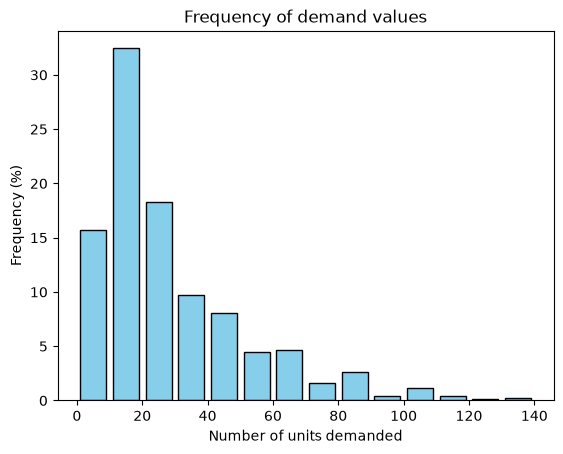

In [35]:
# Frequencies of demand values

# Get the demand data
demand = data['demand'].values

# Calcul of the %
poids = np.ones_like(demand) / len(demand) * 100

# Hist (bins dynamiques basés sur le min et max de la demande)
import numpy as np
min_val = np.min(demand)
max_val = np.max(demand)
plt.hist(demand, bins=np.arange(0, 150, 10), weights=poids, 
         color='skyblue', edgecolor='black', rwidth=0.8)

plt.title("Frequency of demand values")
plt.xlabel("Number of units demanded")
plt.ylabel("Frequency (%)")
plt.show()


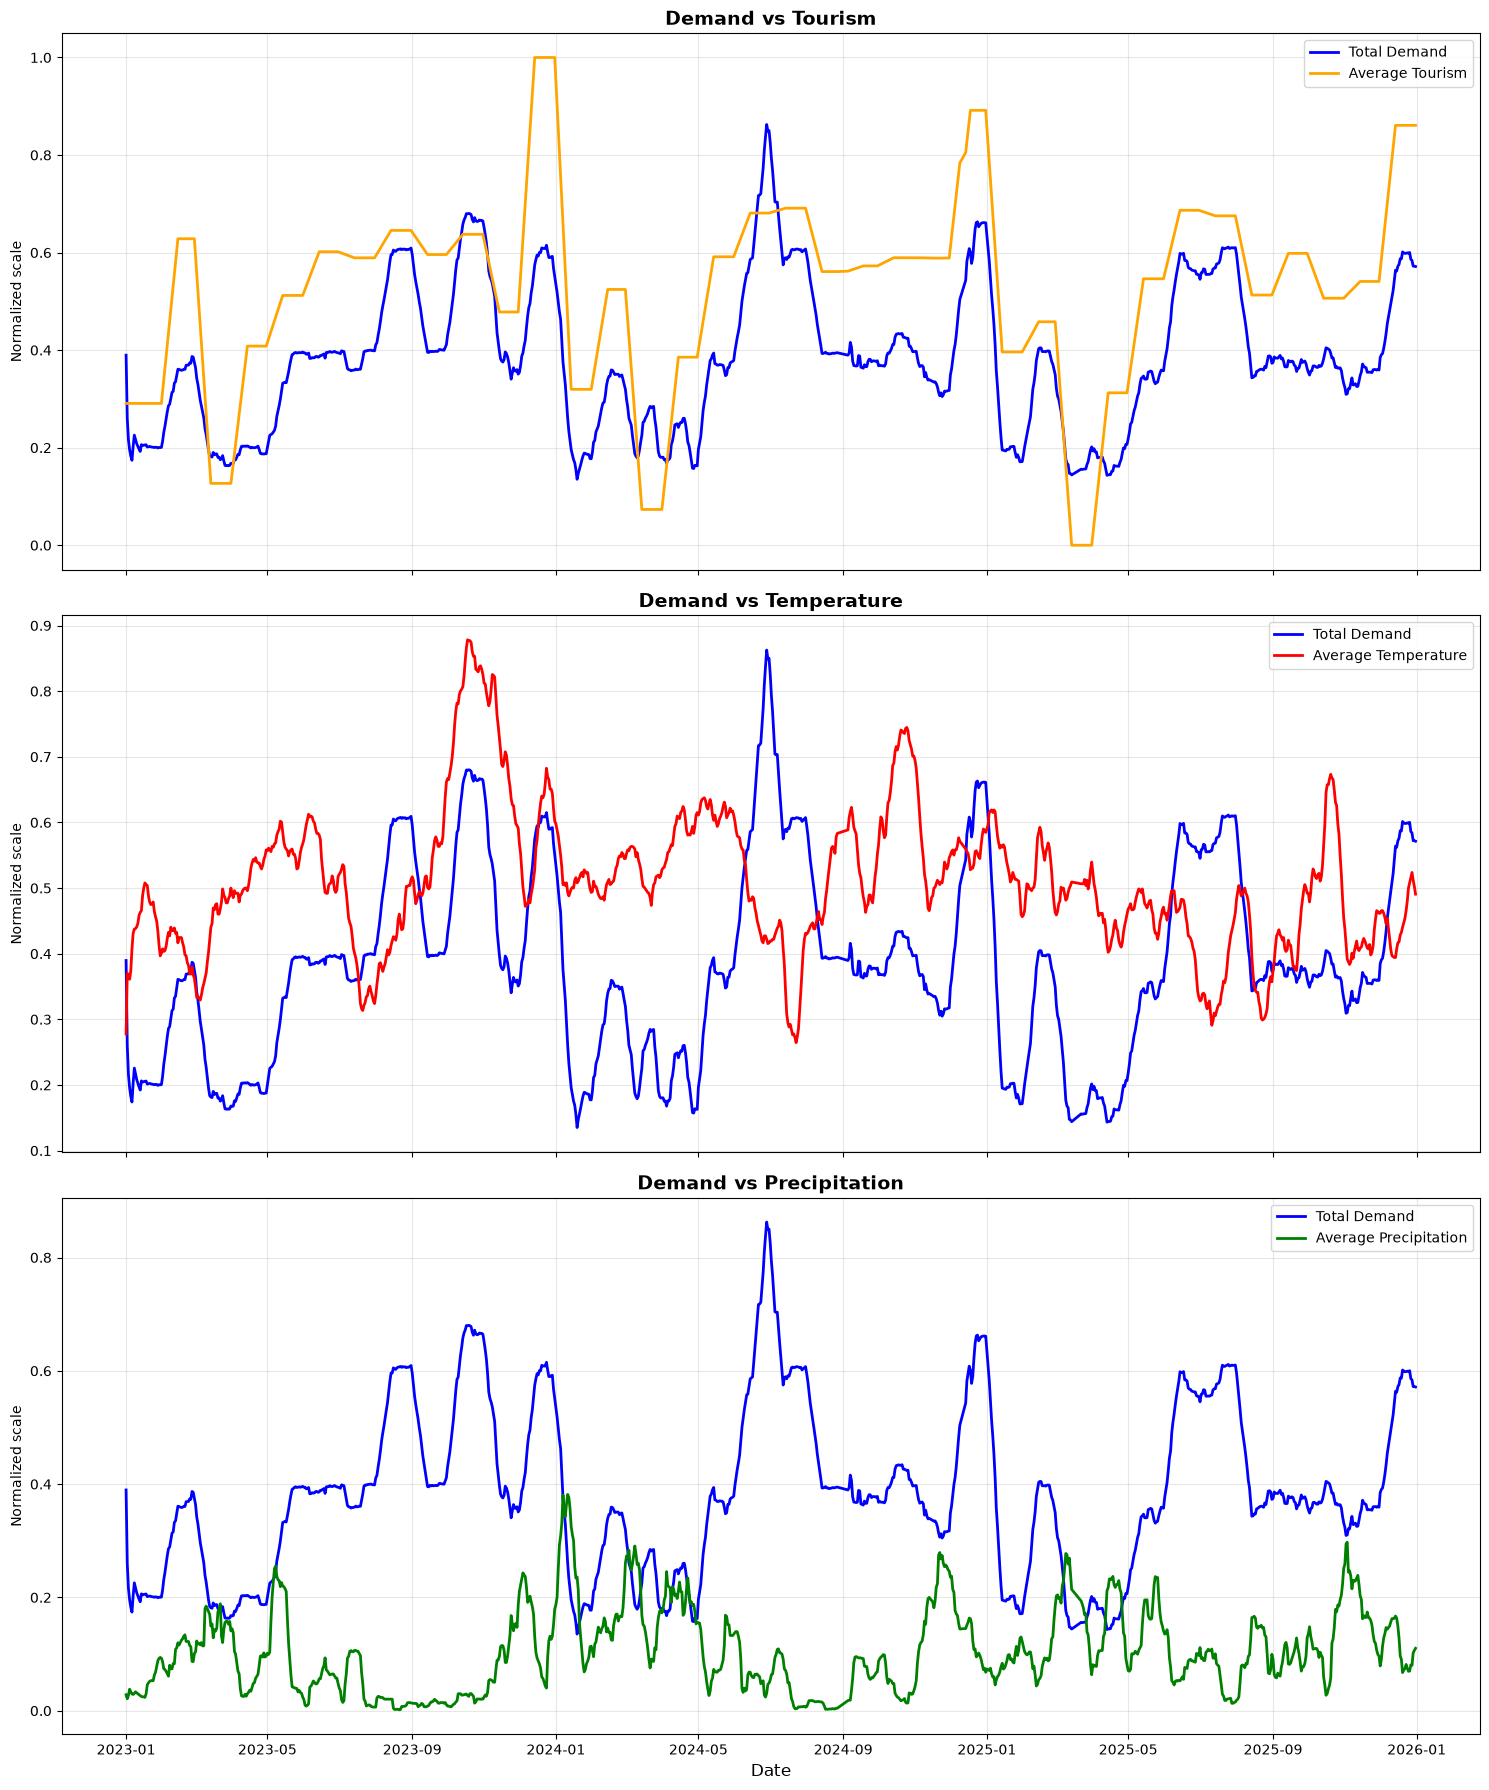

In [36]:
# A- Daily aggregation of the products
daily_data = data.groupby('Date').agg({
    'demand': 'sum',
    'Avg_tourism': 'mean',
    'Avg_temp': 'mean',
    'prcp': 'mean'
}).reset_index()

# B- Scales all values between 0 and 1 to compare them well
scaler = MinMaxScaler()
cols_to_scale = ['demand', 'Avg_tourism', 'Avg_temp', 'prcp']
daily_data_scaled = daily_data.copy()
daily_data_scaled[cols_to_scale] = scaler.fit_transform(daily_data[cols_to_scale])

# 3. Smoothing (14-day rolling average) to eliminate daily noise and make curves highly readable
daily_data_scaled[cols_to_scale] = daily_data_scaled[cols_to_scale].rolling(window=14, min_periods=1).mean()

fig, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=True)

# Chart 1: Demand vs Tourism
sns.lineplot(data=daily_data_scaled, x='Date', y='demand', ax=axes[0], color='blue', label='Total Demand', linewidth=2)
sns.lineplot(data=daily_data_scaled, x='Date', y='Avg_tourism', ax=axes[0], color='orange', label='Average Tourism', linewidth=2)
axes[0].set_title('Demand vs Tourism', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Normalized scale')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Chart 2: Demand vs Temperature
sns.lineplot(data=daily_data_scaled, x='Date', y='demand', ax=axes[1], color='blue', label='Total Demand', linewidth=2)
sns.lineplot(data=daily_data_scaled, x='Date', y='Avg_temp', ax=axes[1], color='red', label='Average Temperature', linewidth=2)
axes[1].set_title('Demand vs Temperature', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Normalized scale')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Chart 3: Demand vs Precipitation
sns.lineplot(data=daily_data_scaled, x='Date', y='demand', ax=axes[2], color='blue', label='Total Demand', linewidth=2)
sns.lineplot(data=daily_data_scaled, x='Date', y='prcp', ax=axes[2], color='green', label='Average Precipitation', linewidth=2)
axes[2].set_title('Demand vs Precipitation', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Normalized scale')
axes[2].set_xlabel('Date', fontsize=12)
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 2.2.3. Correlation

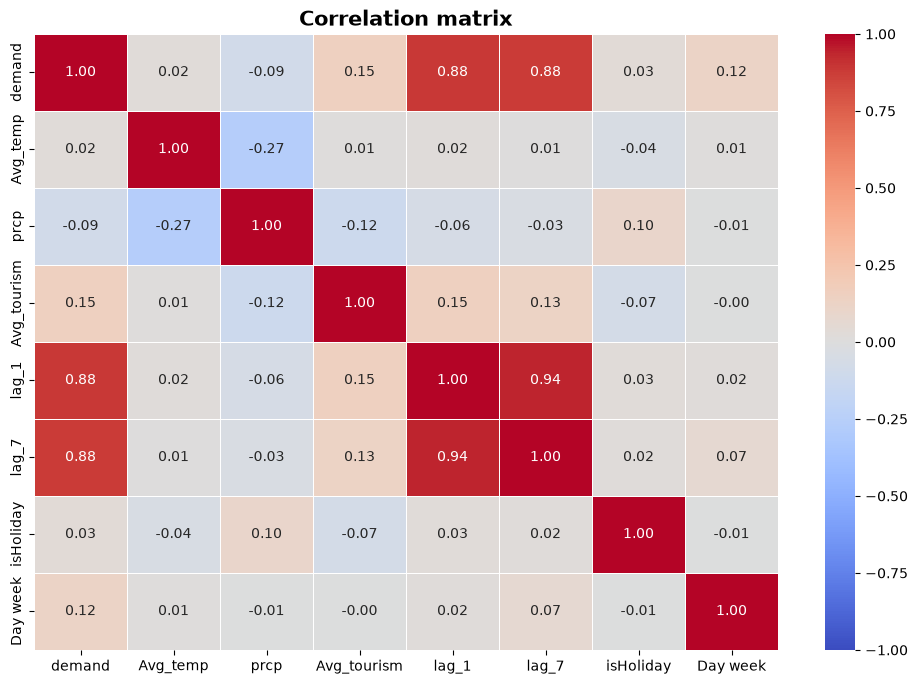

In [37]:
data = data[['demand', 'Avg_temp', 'prcp', 'Avg_tourism', 'lag_1', 'lag_7', 'isHoliday', 'Day week']]
correlation_matrix = data.corr()
plt.figure(figsize=(12, 8))

sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f', 
            linewidths=0.5,
            vmin=-1, 
            vmax=1)

plt.title('Correlation matrix', fontsize=15, fontweight='bold')
plt.show()

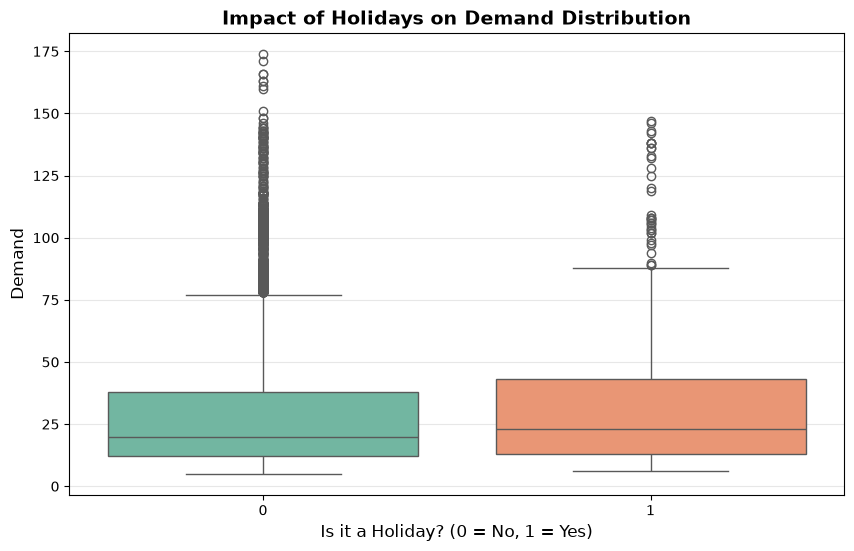

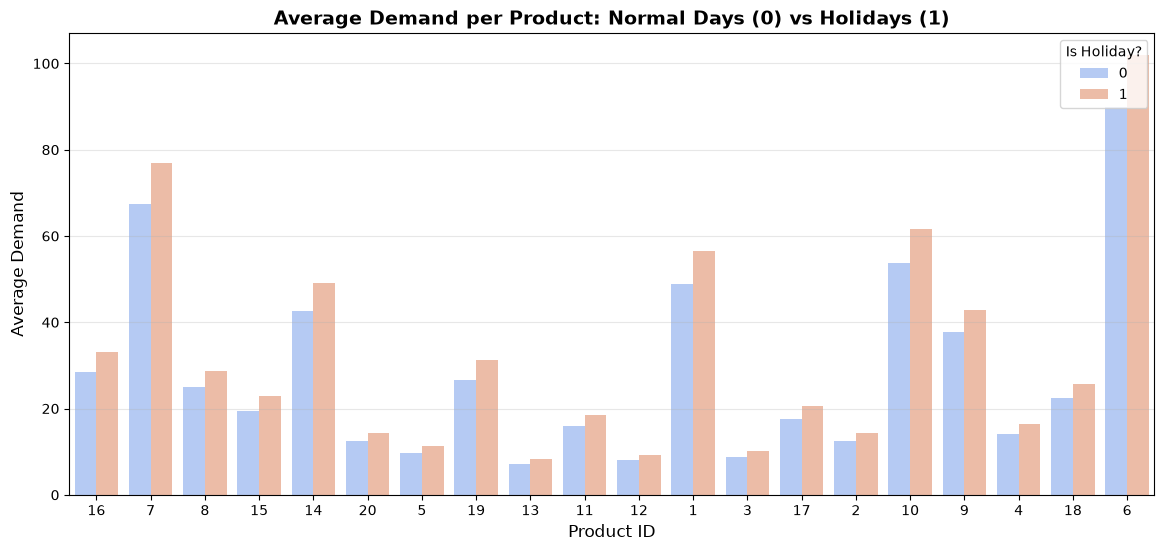

Overall average demand during normal days: 28.43 units
Overall average demand on Holidays: 32.66 units
    Holidays increase the demand by 14.9%


In [ ]:
# Boxplot base on median to check impact of holiday on demand

plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='isHoliday', y='demand', hue='isHoliday', palette='Set2', legend=False)
plt.title('Impact of Holidays on Demand Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Is it a Holiday? (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Demand', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.show()


# Check the exact % of increase in demand on holidays vs normal days
# Using barplot instead of hist as it's category data

plt.figure(figsize=(14, 6))
sns.barplot(data=df_complet, x='id', y='demand', hue='isHoliday', palette='coolwarm', errorbar=None)
plt.title('Average Demand per Product: Normal vs Holidays', fontsize=14, fontweight='bold')
plt.xlabel('Product ID', fontsize=12)
plt.ylabel('Average Demand', fontsize=12)
plt.legend(title='Is Holiday?', loc='upper right')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# Textual summary of the impact:
mean_normal = df_complet[df_complet['isHoliday'] == 0]['demand'].mean()
mean_holiday = df_complet[df_complet['isHoliday'] == 1]['demand'].mean()
increase_pct = ((mean_holiday - mean_normal) / mean_normal) * 100
print(f"Overall average demand during normal days: {mean_normal:.2f} units")
print(f"Overall average demand on Holidays: {mean_holiday:.2f} units")
print(f"    Holidays increase the demand by {increase_pct:.1f}%")

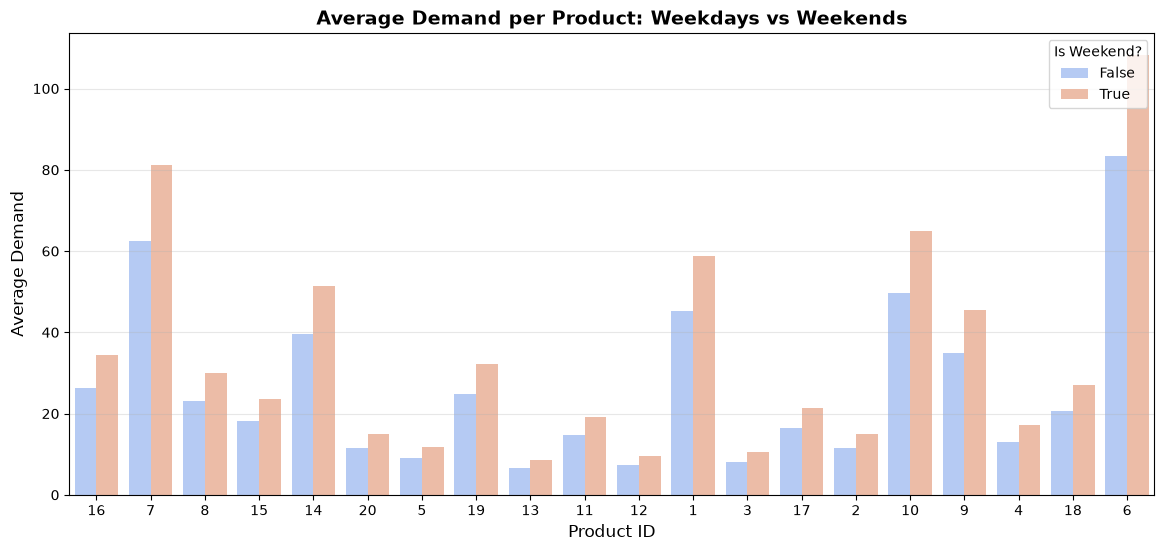

Overall average demand on Weekdays: 26.30 units
Overall average demand on Weekends: 34.28 units
    Weekends change the demand by 30.4%


In [45]:
# Do the same (2nd part) but for the weekends

df_complet['isWeekend'] = df_complet['Day week'] >= 6

plt.figure(figsize=(14, 6))
sns.barplot(data=df_complet, x='id', y='demand', hue='isWeekend', palette='coolwarm', errorbar=None)
plt.title('Average Demand per Product: Weekdays vs Weekends', fontsize=14, fontweight='bold')
plt.xlabel('Product ID', fontsize=12)
plt.ylabel('Average Demand', fontsize=12)
plt.legend(title='Is Weekend?', loc='upper right')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# Textual summary
mean_weekday = df_complet[df_complet['isWeekend'] == False]['demand'].mean()
mean_weekend = df_complet[df_complet['isWeekend'] == True]['demand'].mean()
increase_pct = ((mean_weekend - mean_weekday) / mean_weekday) * 100
print(f"Overall average demand on Weekdays: {mean_weekday:.2f} units")
print(f"Overall average demand on Weekends: {mean_weekend:.2f} units")
print(f"    Weekends change the demand by {increase_pct:.1f}%")

# 3. Data Processing
## 3.1. Data Cleaning

## 3.2. Feature engineering

## 3.3. Clustering 

## 3.4. Time series split

## 4. Forecasting model
## 4.1.  XGBoost
### 4.1.1. Preparation

### 4.1.2. Training

### 4.1.3. Results

## 4.2. Hyperparameter tunning

## 4.3. Optimal model

## 4.4. Long-term strategy
### 4.4.1. Creation

### 4.4.2. Combine both

# 5. Evaluation
## 5.1. Classics metrics

## 5.2. Visualise error

## 5.3. Others
### 5.3.1. Cross-valisation

### 5.3.2. Feature importance analysis

# 6. Real implementation

# 7. Conclusion on everything